# Candle-GPT v2 — Data Exploration

Loads BTCUSDT 1m from the v2 raw store and plots an arbitrary window.

In [1]:
import sys
from pathlib import Path

# When run via `nbconvert --execute`, cwd is the notebook's directory
# (`v2/notebooks/`); the project root (which contains the `v2/` package)
# is two levels up. When run interactively from project root, cwd is
# already correct. Handle both.
_HERE = Path.cwd()
_PROJECT_ROOT = _HERE.parent.parent if _HERE.name == "notebooks" else _HERE
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from v2.data.constants import Asset, Timeframe, KLINE_COLUMNS
from v2.data.store import parquet_path, read_klines
from v2.data.dataset import KlineWindowDataset

ROOT = _PROJECT_ROOT / "v2" / "data" / "raw"
ASSET = Asset.BTC
TIMEFRAME = Timeframe.M1

In [2]:
path = parquet_path(ROOT, ASSET, TIMEFRAME)
df = read_klines(path)
print(f"loaded {len(df):,} bars from {path}")
print(f"first: {pd.Timestamp(df.open_time.iloc[0], unit='ms', tz='UTC')}")
print(f"last:  {pd.Timestamp(df.open_time.iloc[-1], unit='ms', tz='UTC')}")

loaded 2,103,000 bars from /Users/kazkeller/.openclaw/workspace/projects/candle-gpt/v2/data/raw/btcusdt_1m.parquet
first: 2022-05-04 18:09:00+00:00
last:  2026-05-04 05:28:00+00:00


## Plot any window

Set `start_idx` and `window_len` to whatever you want.

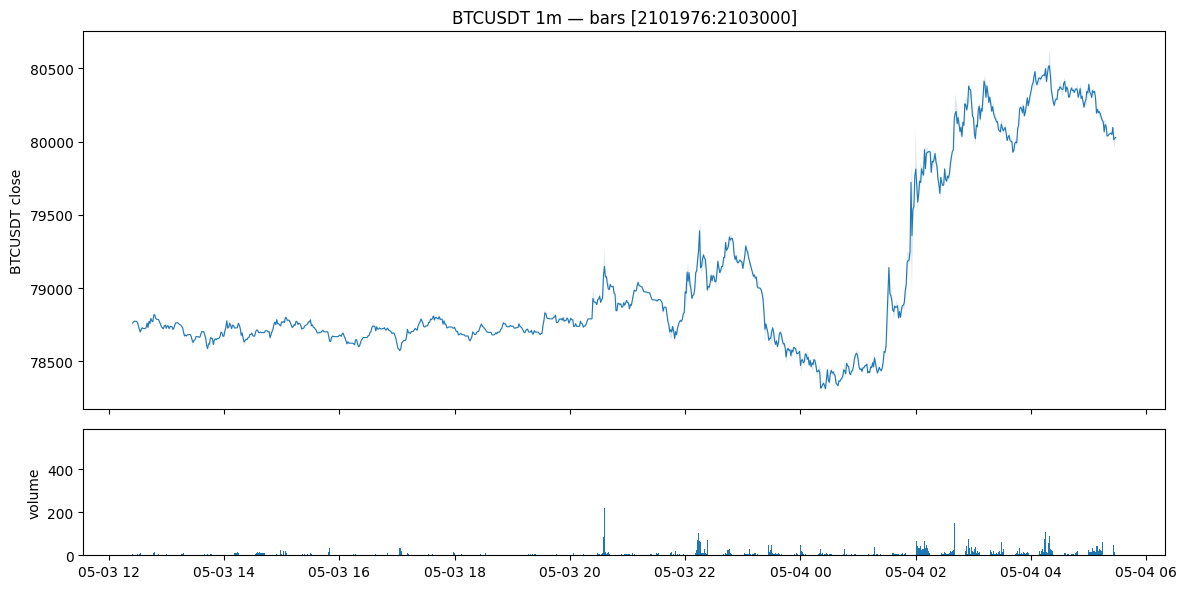

In [3]:
start_idx = len(df) - 1024  # last 1024 bars by default
window_len = 1024

window = df.iloc[start_idx : start_idx + window_len]
ts = pd.to_datetime(window["open_time"], unit="ms", utc=True)

fig, (ax_price, ax_vol) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                        gridspec_kw={"height_ratios": [3, 1]})
ax_price.plot(ts, window["close"], lw=0.8)
ax_price.fill_between(ts, window["low"], window["high"], alpha=0.15, lw=0)
ax_price.set_ylabel(f"{ASSET.value} close")
ax_price.set_title(f"{ASSET.value} {TIMEFRAME.value} — bars [{start_idx}:{start_idx + window_len}]")
ax_vol.bar(ts, window["volume"], width=4e-4)
ax_vol.set_ylabel("volume")
fig.tight_layout()
plt.show()

## Same window via `KlineWindowDataset`

Verifies the Dataset returns the same bars we just plotted.

In [4]:
ds = KlineWindowDataset(path, window=window_len, stride=1)
ds_idx = start_idx  # stride=1 so dataset index == bar index
tensor = ds[ds_idx]
print(f"tensor shape: {tuple(tensor.shape)}")
close_col = list(KLINE_COLUMNS).index("close")
# Dataset stores float32; DataFrame has float64 — use allclose with float32 tolerance.
import numpy as np
assert np.allclose(
    tensor[:, close_col].numpy(),
    window["close"].to_numpy().astype("float32"),
    rtol=0, atol=1e-6,
), "Dataset slice disagrees with raw DataFrame slice"
print("Dataset and raw DataFrame match.")

tensor shape: (1024, 7)
Dataset and raw DataFrame match.
